[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jecampagne/nufftcf/blob/main/notebook/nufftcf_astro_demo.ipynb)


# `nufftcf` on a synthetic astro-like light curve

**Goal.** This notebook demonstrates `nufftcf` on a synthetic light curve
that mimics a real stellar time series, combining:

1. **Stellar rotation** — a quasi-periodic signal (sinusoid of period
   `P_rot`) whose amplitude evolves slowly, mimicking spot evolution /
   differential rotation;
2. **Intrinsic correlated noise** — a fast Ornstein–Uhlenbeck (OU) process
   (flicker-noise / granulation type);
3. **Ground-based survey sampling** — a seasonal observability window plus
   nights lost to weather (gaps, not just uniform sub-sampling);
4. **Heteroscedastic measurement noise** — a per-point `sigma_i` (variable
   seeing/airmass).

The analytic autocorrelation function (ACF) of the latent process (modulated
rotation + OU noise) is known, which lets us compare the ACF recovered by
`nufftcf` directly against ground truth. A cross-correlation section then
reuses a shared OU process between two "bands" offset by a known delay
`tau0`, with different sampling and noise per band, to check that
`compute_ccf_*` recovers `tau0`.

In [1]:
# Installation from PyPI
!pip install -q nufftcf

import numpy as np
import matplotlib.pyplot as plt

from nufftcf import (
    compute_acf_gaussian_nufft,
    compute_acf_gaussian_realspace,
    compute_acf_rectangle_nufft,
    compute_acf_rectangle_realspace,
    compute_ccf_gaussian_nufft,
    compute_ccf_gaussian_realspace,
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (9, 3.5)

import matplotlib as mpl
mpl.rcParams.update({
    'font.size'         : 13,
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 14,
    'xtick.labelsize'   : 14,
    'ytick.labelsize'   : 14,
    'legend.fontsize'   : 12,
    'figure.titlesize'  : 16,
    'figure.titleweight': 'bold',
})


rng = np.random.default_rng(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 45.0 MB/s eta 0:00:00


## 1. Physical model

The latent flux (before sampling/measurement noise) is modeled as

$$
y(t) = \underbrace{A(t)\,\cos\!\big(2\pi t/P_{\rm rot} + \varphi\big)}_{\text{stellar rotation}}
\;+\; \underbrace{n(t)}_{\text{correlated noise (OU)}}
$$

where:

- $\varphi$ is a fixed phase drawn uniformly on $[0,2\pi)$;
- $A(t)$ is a *stationary* Ornstein–Uhlenbeck process with mean $A_0$,
  variance $\sigma_A^2$ and correlation time $\tau_A \gg P_{\rm rot}$ (slow
  evolution of the modulation amplitude):
  $\mathrm{Cov}[A(t),A(t+\tau)]=\sigma_A^2 e^{-|\tau|/\tau_A}$
- $n(t)$ is a second, independent OU process with zero mean, variance
  $\sigma_n^2$ and correlation time $\tau_n$ (intermediate-scale correlated
  noise, granulation/flicker type):
  $\mathrm{Cov}[n(t),n(t+\tau)]=\sigma_n^2 e^{-|\tau|/\tau_n}$

**Analytic ACF.** Since $\varphi$ is independent of $A(t)$ and uniform on
$[0,2\pi)$, $\mathbb E[\cos(\omega t+\varphi)\cos(\omega(t+\tau)+\varphi)]
= \tfrac12\cos(\omega\tau)$, giving the autocovariance of the rotation term:

$$
\mathrm{Cov}_{\rm rot}(\tau) = \frac{1}{2}\cos(2\pi\ \tau/P_{\rm rot})\,\big(\sigma_A^2 e^{-|\tau|/\tau_A} \ + A_0^2\big)
$$

This is a *quasi-periodic* kernel (the one used in GP models of stellar
rotation). Adding the independent correlated-noise contribution,
$$\mathrm{Cov}_{\rm tot}(\tau) = \mathrm{Cov}_{\rm rot}(\tau) + \sigma_n^2 e^{-|\tau|/\tau_n}$$
gives the **theoretical normalized ACF of the latent process**:

$$
\rho_{\rm true}(\tau) = \frac{\mathrm{Cov}_{\rm tot}(\tau)}{\mathrm{Cov}_{\rm tot}(0)}
$$

**Note.** The heteroscedastic measurement noise added later is a white noise,
independent per point: it only contributes at lag 0 (a so-called "nugget" effect) and
lowers the observed total variance $\mathrm{Var}(x_{\rm obs}) =
\mathrm{Cov}_{\rm tot}(0) + \langle\sigma_i^2\rangle$. `nufftcf` standardizes
the data before computing the ACF, so the *observed* ACF at $\tau>0$ is
$\rho_{\rm true}(\tau)\times \mathrm{Cov}_{\rm tot}(0)/\mathrm{Var}(x_{\rm obs})$:
a slightly rescaled version of $\rho_{\rm true}$, with the same shape — this
is exactly what we will check below.

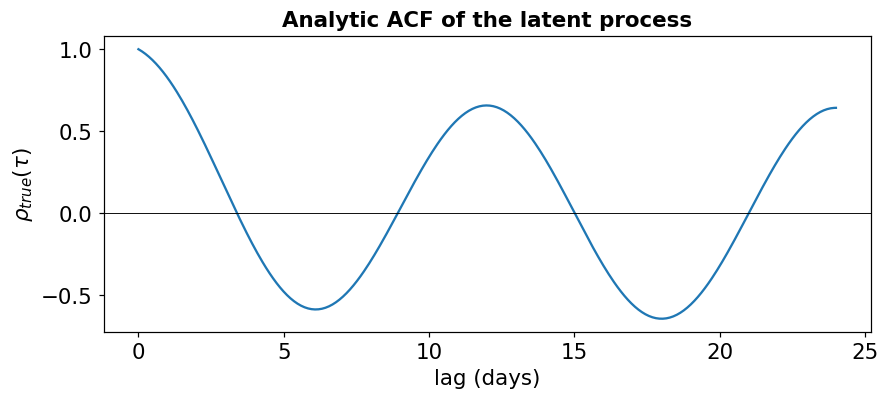

In [2]:
# Physical parameters
P_rot   = 12.0          # stellar rotation period (days)
A0      = 1.0              # mean amplitude of the rotation modulation
sigma_A = 0.35       # amplitude of the spot evolution (std of the slow OU)
tau_A   = 220.0        # correlation time of the spot evolution (days), >> P_rot

sigma_n = 0.55      # std of the intrinsic correlated noise (flicker/granulation)
tau_n   = 3.5          # correlation time of the correlated noise (days)

def acf_true(tau, P_rot=P_rot, A0=A0, sigma_A=sigma_A, tau_A=tau_A,
             sigma_n=sigma_n, tau_n=tau_n):
    '''Analytic, normalized ACF of the latent process y(t)'''
    tau = np.asarray(tau, dtype=float)
    cov_rot = 0.5 * np.cos(2 * np.pi * tau / P_rot) * (sigma_A**2 * np.exp(-np.abs(tau) / tau_A) + A0**2)
    cov_n   = sigma_n**2 * np.exp(-np.abs(tau) / tau_n)
    cov_tot = cov_rot + cov_n
    cov0 = 0.5 * (sigma_A**2 + A0**2) + sigma_n**2
    return cov_tot / cov0

lags_plot = np.linspace(0, 2 * P_rot, 400)
plt.plot(lags_plot, acf_true(lags_plot))
plt.axhline(0, color="k", lw=0.6)
plt.xlabel("lag (days)"); plt.ylabel(r"$\rho_{true}(\tau)$")
plt.title("Analytic ACF of the latent process")
plt.show()

## 2. Exact simulation of the latent process (irregular sampling)

An OU process admits an exact transition, even for a non-constant time
step $\Delta t$:

$$
X(t+\Delta t) = \mu + (X(t)-\mu)\,e^{-\Delta t/\tau} + \sigma\sqrt{1-e^{-2\Delta t/\tau}}\;\varepsilon,\qquad \varepsilon\sim\mathcal N(0,1)
$$

so $A(t_i)$ and $n(t_i)$ can be generated **directly at the real
observation epochs** (irregular), with no need of a dense-grid discretization.

In [3]:
def simulate_ou_at(t, mu, sigma, tau, rng):
    '''Simulate a stationary OU process at instants t (sorted, irregular).'''
    t = np.asarray(t, dtype=float)
    n = len(t)
    x = np.empty(n)
    x[0] = mu + sigma * rng.standard_normal()
    for i in range(1, n):
        dt = t[i] - t[i - 1]
        phi = np.exp(-dt / tau)
        x[i] = mu + (x[i - 1] - mu) * phi + sigma * np.sqrt(1 - phi**2) * rng.standard_normal()
    return x


def latent_signal_at(t, phi0, rng):
    '''y(t) = A(t) cos(2 pi t / P_rot + phi0) + n(t), at instants t (irregular).'''
    A = simulate_ou_at(t, A0, sigma_A, tau_A, rng)
    n = simulate_ou_at(t, 0.0, sigma_n, tau_n, rng)
    y = A * np.cos(2 * np.pi * t / P_rot + phi0) + n
    return y, A, n

## 3. Ground-based "survey" sampling

We simulate a nightly photometric survey spanning several years:

- **one epoch per observing night** (nightly-binned photometry);
- a **seasonal observability window**: the star is only observable for
  ~8 months per year (solar conjunction the rest of the year), producing
  **structured gaps**, not just random holes;
- **weather losses**: ~25% of otherwise-observable nights are lost to
  clouds, adding random sparsity;
- **heteroscedastic measurement noise**: each point has its own $\sigma_i$,
  drawn from a seeing/airmass proxy (larger near the edges of the season,
  when the target sits lower on the horizon).

762 points over 1403 days (198 points/year on average, median cadence 1.00 d)
sigma_obs: min=0.066, median=0.177, max=0.428


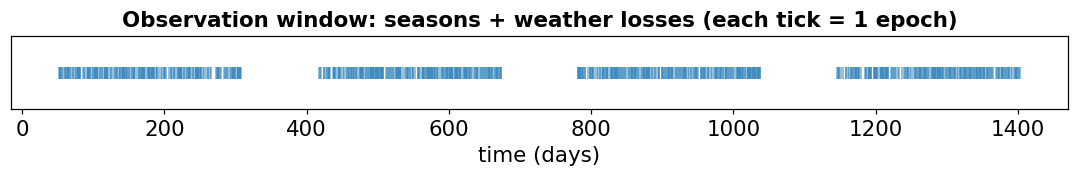

In [4]:
def survey_sampling_times_nightly(n_years=4.0, season_center_doy=180, season_halfwidth=130,
                                   weather_loss=0.25, rng=rng):
    '''Observation epochs (days since t0): one nightly epoch, seasonal window,
    random weather losses. Also returns the day-of-year (for the heteroscedastic sigma).'''
    n_days_total = int(n_years * 365.25)
    days = np.arange(n_days_total)
    doy = days % 365

    # angular distance to the season center (within [-182.5, 182.5])
    delta = (doy - season_center_doy + 182.5) % 365 - 182.5
    observable = np.abs(delta) < season_halfwidth

    clear_night = rng.random(n_days_total) > weather_loss
    kept = observable & clear_night

    t = days[kept].astype(float)
    doy_kept = doy[kept]
    order = np.argsort(t)
    return t[order], doy_kept[order]


def heteroscedastic_sigma(doy, season_center_doy=180, sigma_min=0.08, sigma_max=0.35, rng=rng):
    '''sigma_i grows away from the season center (airmass proxy), plus proxy jitter.'''
    delta = np.abs((doy - season_center_doy + 182.5) % 365 - 182.5)
    x = delta / delta.max()
    base = sigma_min + (sigma_max - sigma_min) * x**1.5
    jitter = rng.uniform(0.8, 1.25, size=len(doy))
    return base * jitter


t_obs, doy_obs = survey_sampling_times_nightly(n_years=4.0)
sigma_obs = heteroscedastic_sigma(doy_obs)

print(f"{len(t_obs)} points over {t_obs.max():.0f} days "
      f"({len(t_obs)/(t_obs.max()/365.25):.0f} points/year on average, "
      f"median cadence {np.median(np.diff(t_obs)):.2f} d)")
print(f"sigma_obs: min={sigma_obs.min():.3f}, median={np.median(sigma_obs):.3f}, max={sigma_obs.max():.3f}")

# Sampling window (visualizing the gaps)
plt.figure(figsize=(10, 1.8))
plt.plot(t_obs, np.zeros_like(t_obs), "|", color="C0", markersize=8, alpha=0.6)
plt.yticks([])
plt.xlabel("time (days)")
plt.title("Observation window: seasons + weather losses (each tick = 1 epoch)")
plt.tight_layout()
plt.show()

## 4. Generating the observed light curve

$$x_{\rm obs}(t_i) = y(t_i) + \varepsilon_i,\qquad \varepsilon_i \sim \mathcal N(0,\sigma_i^2)$$

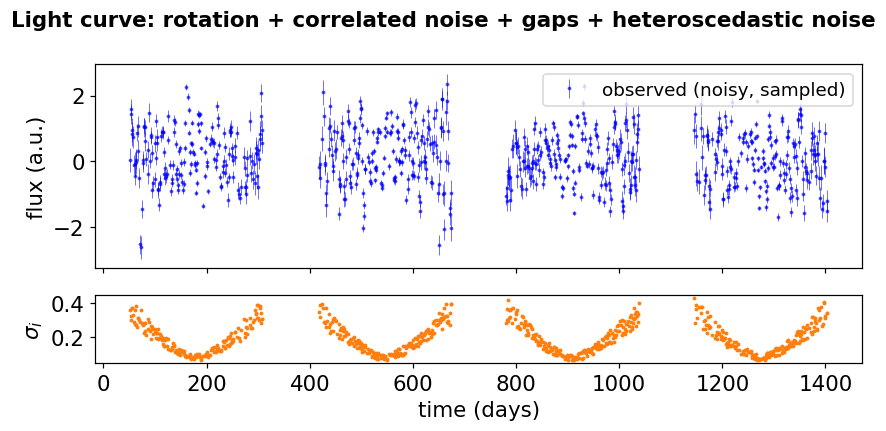

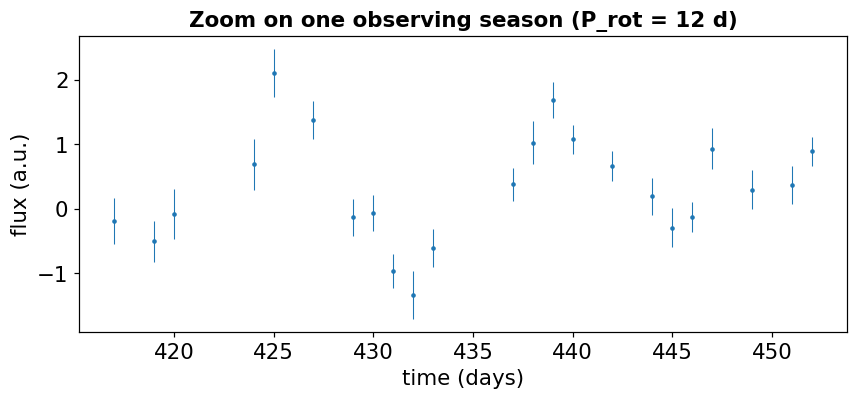

In [18]:
phi0 = rng.uniform(0, 2 * np.pi)
y_latent, A_t, n_t = latent_signal_at(t_obs, phi0, rng)
x_obs = y_latent + sigma_obs * rng.standard_normal(len(t_obs))

fig, axes = plt.subplots(2, 1, figsize=(8, 4), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1]})

axes[0].errorbar(t_obs, x_obs, yerr=sigma_obs, fmt=".", ms=3, elinewidth=0.6,
                  alpha=0.6, color="blue", label="observed (noisy, sampled)")
axes[0].legend(loc="upper right")
axes[0].set_ylabel("flux (a.u.)")
fig.suptitle("Light curve: rotation + correlated noise + gaps + heteroscedastic noise",
             fontsize=14)

axes[1].plot(t_obs, sigma_obs, ".", ms=3, color="C1")
axes[1].set_ylabel(r"$\sigma_i$")
axes[1].set_xlabel("time (days)")

plt.tight_layout()
plt.savefig("astro_lightcurve.pdf", format="pdf", bbox_inches="tight", dpi=200)
plt.show()

# Zoom on one season to see the rotation modulation and the correlated noise
mask_zoom = (t_obs > 365) & (t_obs < 365 + 90)
plt.figure()
plt.errorbar(t_obs[mask_zoom], x_obs[mask_zoom], yerr=sigma_obs[mask_zoom],
             fmt=".", ms=4, elinewidth=0.7, color="C0")
plt.xlabel("time (days)"); plt.ylabel("flux (a.u.)")
plt.title(f"Zoom on one observing season (P_rot = {P_rot:.0f} d)")
plt.show()

## 5. ACF estimation with `nufftcf`

We compute the ACF with both `compute_acf_gaussian_realspace` and
`compute_acf_gaussian_nufft` on the sparse, heteroscedastic light curve.
`bin_width` is chosen fine enough to resolve both the correlated-noise time
scale `tau_n` and the rotation period `P_rot`, and `lags` are requested on
an integer-day grid matching the nightly cadence of the survey.

In [6]:
# start at 1. as nufftcf remove lag=0 from the return
lags = np.arange(1.0, 50.0, 1.0)   # integer-day lags, matching the nightly cadence

c_real, b_real   = compute_acf_gaussian_realspace(lags, t_obs, x_obs, bin_width=0.5)
c_nufft, b_nufft = compute_acf_gaussian_nufft(lags, t_obs, x_obs, bin_width=0.5)

rho_theo = acf_true(lags)

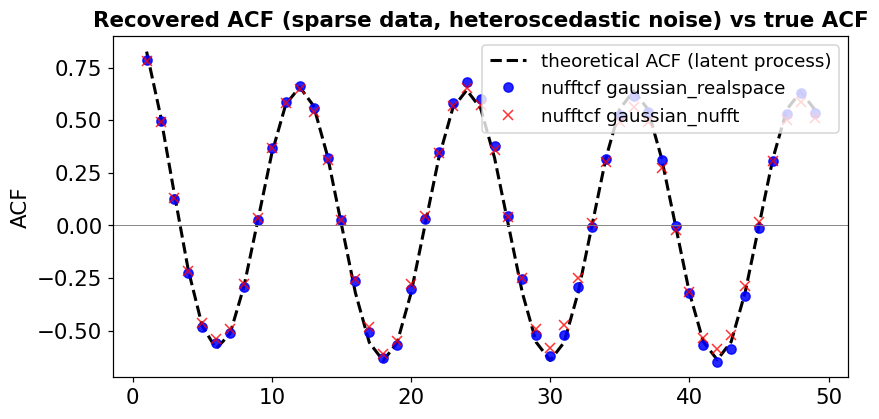

N=762  RMSE gaussian_realspace=0.0268  RMSE gaussian_nufft=0.0402


In [20]:
#Plot

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

ax.plot(lags, rho_theo, "k--", lw=2, label="theoretical ACF (latent process)")
ax.plot(lags, c_real, "o", ms=6, color="blue", alpha=0.85, label="nufftcf gaussian_realspace")
ax.plot(lags, c_nufft, "x", ms=6, color="red", alpha=0.8, label="nufftcf gaussian_nufft")
ax.axhline(0, color="grey", lw=0.6)
ax.set_ylabel("ACF")
ax.legend(loc="upper right")
ax.set_title("Recovered ACF (sparse data, heteroscedastic noise) vs true ACF")

plt.tight_layout()
plt.savefig("astro_ACF_nufft.pdf", format="pdf", bbox_inches="tight", dpi=200)
plt.show()

rmse_real  = np.sqrt(np.mean((c_real - rho_theo) ** 2))
rmse_nufft = np.sqrt(np.mean((c_nufft - rho_theo) ** 2))
print(f"N={len(t_obs)}  RMSE gaussian_realspace={rmse_real:.4f}  RMSE gaussian_nufft={rmse_nufft:.4f}")

## 6. Quantitative check

We extract two quantities directly from the recovered ACF and compare them
to the injected values: the **rotation period** `P_rot` (ACF peak in a
search window) and the **intrinsic noise correlation time** `tau_n` (fit to
the short lags).

**On the fit model.** A naive single exponential does not fit the short-lag
ACF: over `lags_short` (up to ~14 d), the rotation term `cos(2*pi*tau/P_rot)`
is *not* slowly varying (`P_rot=12` d), so the short-lag shape is a mix of
the rotation oscillation and the OU decay, not a pure decay. We therefore
fit the correct composite shape instead.

A first version of this composite fit,
`offset + amp_rot*cos(...) + amp_n*exp(-tau/tau_n_fit)`, renormalized by its
own value at `tau=0` (`.../(offset+amp_rot+amp_n)`), turned out to have an
**exact scale degeneracy**: multiplying `(offset, amp_rot, amp_n)` by any
common factor `k` leaves the renormalized curve unchanged, so those three
parameters are only identifiable through their *ratios*, not individually.
`curve_fit`'s covariance matrix (built from the Jacobian) is then singular
along that direction, producing the enormous, meaningless formal errors
seen on `amp_rot`, `amp_n`, `offset` (while `tau_n_fit` and `P_rot`, which
affect the *shape* rather than just the overall scale, stayed well
constrained). The fix is to remove the redundant degree of freedom: replace
`(amp_rot, amp_n, offset)` by a single mixture weight
`w = amp_rot/(amp_rot+amp_n) in [0,1]` (dropping `offset`, which has no
counterpart in `acf_true` anyway).

**On the residual bias.** Even with that fix, `tau_n_fit` recovered from the
*observed* (noisy, sampled) ACF is systematically low compared to the
injected `tau_n` (checked by averaging over many independent survey
realizations). This is not a `nufftcf` artifact: fitting the same model to
the noiseless theoretical `acf_true(tau)` recovers the injected values
almost exactly. The culprit is the heteroscedastic measurement noise
`sigma_i`: it inflates the *observed* variance without adding any genuine
covariance at `tau>0`, so the empirical, variance-normalized ACF at `tau>0`
is a *diluted* version of the latent process's true ACF,
`rho_obs(tau) = kappa * rho_true(tau)` with
`kappa = Cov_tot(0) / Var(x_obs) = Cov_tot(0) / (Cov_tot(0) + <sigma_i^2>) < 1`
(this is exactly the dilution noted in Section 1). The previous model had no
way to represent this uniform amplitude deficit — pinned to `1` at `tau=0`
by construction — so the fit was compensating for it by *distorting the
decay shape* (effectively pulling `tau_n_fit` down). Adding `kappa` as an
explicit free (or independently cross-checked) parameter removes that
compensation.

In [8]:
from scipy.optimize import curve_fit

In [9]:
lags_short = np.arange(1., 15.0, 1) # start at 1. as nufftcf remove lag=0 from the return
c_short_r, _ = compute_acf_rectangle_realspace(lags_short, t_obs, x_obs, bin_width=0.5)
c_short_n, _ = compute_acf_rectangle_nufft(lags_short, t_obs, x_obs, bin_width=0.5)
truth =  acf_true(lags_short)

In [10]:
def print_para(names, par, perr):
    for name, p, sig in zip(names, par, perr):
        print(f"  {name:10s} = {p:8.4f} +/- {sig:.4f}")

# --- rotation period: ACF peak closest to P_rot within a search window ---
search_mask = (lags > 0.4 * P_rot) & (lags < 1.6 * P_rot)
P_rot_recovered_real  = lags[search_mask][np.argmax(c_real[search_mask])]
P_rot_recovered_nufft = lags[search_mask][np.argmax(c_nufft[search_mask])]
print(f"P_rot injected = {P_rot:.2f} d  |  recovered (ACF peak): "
      f"realspace = {P_rot_recovered_real:.2f} d, nufft = {P_rot_recovered_nufft:.2f} d")

# --- tau_n: composite fit (rotation + OU decay) on the short lags ---
param_names = ["w", "tau_n_fit", "P_rot", "kappa"]

def model_nugget(tau, w, tau_n_fit, P_rot, kappa):
    """Normalized latent-process ACF (rotation term of weight w, OU decay
    of weight 1-w, both pinned to sum to 1 at tau=0), rescaled by the
    measurement-noise dilution factor kappa = Cov_tot(0)/Var(x_obs).
    kappa=1 <=> noiseless / no measurement-noise dilution."""
    rho_true_ = w * np.cos(2 * np.pi * tau / P_rot) + (1 - w) * np.exp(-tau / tau_n_fit)
    return kappa * rho_true_


# independent, data-driven cross-check of kappa (does NOT use the ACF fit):
# Var(x_obs) = Cov_tot(0) + <sigma_i^2>  =>  kappa = 1 - <sigma_i^2>/Var(x_obs)
kappa_est = 1.0 - np.mean(sigma_obs**2) / np.var(x_obs, ddof=1)
print(f"kappa cross-check from Var(x_obs) and <sigma_obs^2> (independent of the ACF fit): "
      f"kappa_est = {kappa_est:.3f}")

print("\n--- realspace ---")
bounds_nugget = ([0., 0.1, 1., 0.01], [1., P_rot_recovered_real*1.5, P_rot_recovered_real*1.5, 1.0])
p0_nugget = [0.5, 3.0, P_rot_recovered_real, 0.9]

popt_r, pcov_r = curve_fit(model_nugget, lags_short, c_short_r,
                            p0=p0_nugget, bounds=bounds_nugget)
perr_r = np.sqrt(np.diag(pcov_r))
print_para(param_names, popt_r, perr_r)

print("\n--- nufft ---")
bounds_nugget = ([0., 0.1, 1., 0.01], [1., P_rot_recovered_nufft*1.5, P_rot_recovered_nufft*1.5, 1.0])
p0_nugget = [0.5, 3.0, P_rot_recovered_nufft, 0.9]

popt_n, pcov_n = curve_fit(model_nugget, lags_short, c_short_n,
                            p0=p0_nugget, bounds=bounds_nugget)
perr_n = np.sqrt(np.diag(pcov_n))
print_para(param_names, popt_n, perr_n)

P_rot injected = 12.00 d  |  recovered (ACF peak): realspace = 12.00 d, nufft = 12.00 d
kappa cross-check from Var(x_obs) and <sigma_obs^2> (independent of the ACF fit): kappa_est = 0.954

--- realspace ---
  w          =   0.7084 +/- 0.0156
  tau_n_fit  =   4.0935 +/- 0.3774
  P_rot      =  11.9654 +/- 0.0231
  kappa      =   0.9378 +/- 0.0190

--- nufft ---
  w          =   0.6973 +/- 0.0159
  tau_n_fit  =   4.1581 +/- 0.3822
  P_rot      =  11.9430 +/- 0.0244
  kappa      =   0.9403 +/- 0.0197


### Monte-Carlo over multiple survey realizations

A single realization is not enough to tell a real bias from sampling
noise. We repeat
the full pipeline -- survey sampling, heteroscedastic noise, latent signal,
observed light curve, NUFFT ACF, `model_nugget` fit -- over `n_mc`
independent realizations (different seeds), for the same three series  (`acf_true`, `y_latent`, `x_obs`), and report the mean, std, and
standard error on the mean (SEM) of `tau_n_fit` (and of `kappa` where
relevant). This is what lets us say whether the injected `tau_n` is
recovered *on average*, and how much scatter to expect from a single run.

In [11]:
from scipy.optimize import OptimizeWarning
import warnings

def one_realization_fits(seed, lags_short=lags_short):
    """Run the full simulation + NUFFT ACF + model_nugget fit for one
    survey realization; return (tau_n_fit, kappa) for the 'true', 'latent'
    and 'obs' cases (NaN if a fit fails to converge)."""
    r = np.random.default_rng(seed)
    t_o, doy_o = survey_sampling_times_nightly(n_years=4.0, rng=r)
    sig_o = heteroscedastic_sigma(doy_o, rng=r)
    phi = r.uniform(0, 2 * np.pi)
    y_l, _, _ = latent_signal_at(t_o, phi, r)
    x_o = y_l + sig_o * r.standard_normal(len(t_o))

    c_lat, _ = compute_acf_gaussian_nufft(lags_short, t_o, y_l, bin_width=0.5)
    c_obs, _ = compute_acf_gaussian_nufft(lags_short, t_o, x_o, bin_width=0.5)

    b_true   = ([0., 0.1, 5., 0.999], [1., 15., 15., 1.0])
    b_latent = ([0., 0.1, 5., 0.5],   [1., 15., 15., 1.0])
    b_obs    = ([0., 0.1, 5., 0.01],  [1., 15., 15., 1.0])

    out = {}
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", OptimizeWarning)
        for key, y, bnds, kappa0 in [("true",   acf_true(lags_short), b_true,   1.0),
                                      ("latent", c_lat,                b_latent, 0.95),
                                      ("obs",    c_obs,                 b_obs,    0.95)]:
            try:
                popt, _ = curve_fit(model_nugget, lags_short, y,
                                     p0=[0.5, 3.0, 12.0, kappa0], bounds=bnds)
                out[key] = (popt[1], popt[3])  # (tau_n_fit, kappa)
            except RuntimeError:
                out[key] = (np.nan, np.nan)
    return out

n_mc = 20
tau_mc   = {"true": [], "latent": [], "obs": []}
kappa_mc = {"latent": [], "obs": []}

for seed in range(n_mc):
    out = one_realization_fits(seed)
    for key in ("true", "latent", "obs"):
        tau_val, kappa_val = out[key]
        tau_mc[key].append(tau_val)
        if key != "true":
            kappa_mc[key].append(kappa_val)

print(f"Monte-Carlo over {n_mc} independent survey realizations:\n")
for key in ("true", "latent", "obs"):
    a = np.array(tau_mc[key])
    a = a[~np.isnan(a)]
    print(f"tau_n_fit [{key:6s}]: mean={a.mean():.3f}  std={a.std():.3f}  "
          f"sem={a.std()/np.sqrt(len(a)):.3f}  (n={len(a)}/{n_mc} converged)")
for key in ("latent", "obs"):
    a = np.array(kappa_mc[key])
    a = a[~np.isnan(a)]
    print(f"kappa     [{key:6s}]: mean={a.mean():.3f}  std={a.std():.3f}")
print(f"\n(tau_n injected = {tau_n:.2f} d)")



Monte-Carlo over 20 independent survey realizations:

tau_n_fit [true  ]: mean=3.464  std=0.000  sem=0.000  (n=20/20 converged)
tau_n_fit [latent]: mean=3.635  std=0.861  sem=0.193  (n=20/20 converged)
tau_n_fit [obs   ]: mean=3.595  std=1.091  sem=0.244  (n=20/20 converged)
kappa     [latent]: mean=0.968  std=0.038
kappa     [obs   ]: mean=0.938  std=0.057

(tau_n injected = 3.50 d)


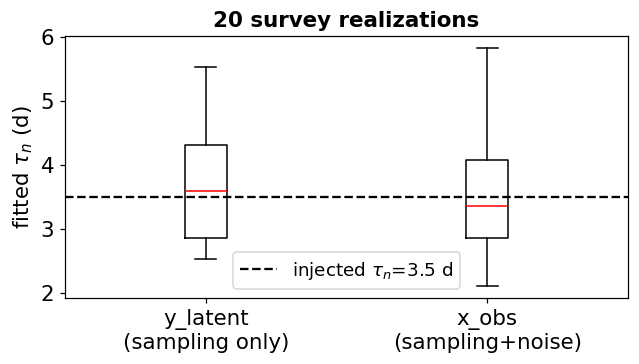

In [12]:
fig, ax = plt.subplots(figsize=(6, 3.5))
data_box = [np.array(tau_mc[k])[~np.isnan(tau_mc[k])] for k in ("latent", "obs")]
boxplot= ax.boxplot(data_box, tick_labels=["y_latent\n(sampling only)", "x_obs\n(sampling+noise)"])
for median in boxplot['medians']:
    median.set_color('red')
ax.axhline(tau_n, color="k", ls="--", lw=1.5, label=f"injected $\\tau_n$={tau_n:.1f} d")
ax.set_ylabel(r"fitted $\tau_n$ (d)")
ax.set_title(fr"{n_mc} survey realizations")
ax.legend()
plt.savefig("astro_taun_multi.pdf", format="pdf", bbox_inches="tight", dpi=200)
plt.tight_layout()